# SafeFactory 🛠
A Dsecision-making support framework for estimating the failure for equipments, cost, and decide the root cause and priority for the failure and give some recommendations.

---
## 1. import libraries and upload data







In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("stephanmatzka/predictive-maintenance-dataset-ai4i-2020")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'predictive-maintenance-dataset-ai4i-2020' dataset.
Path to dataset files: /kaggle/input/predictive-maintenance-dataset-ai4i-2020


In [3]:
print(os.listdir(path))

['ai4i2020.csv']


## Read the data

here we just uploaded the data and just print the shape and head

In [4]:
df_ai4i = pd.read_csv(f'{path}/ai4i2020.csv')
rows, cols = df_ai4i.shape
print(f'data has been downloaded successfully, shape: {rows} rows, {cols} columns.\n\nFirst 5 rows:')
df_ai4i.head()

data has been downloaded successfully, shape: 10000 rows, 14 columns.

First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
for col in df_ai4i.columns:
    print(f"{col}: {df_ai4i[col].nunique()}\n")

UDI: 10000

Product ID: 10000

Type: 3

Air temperature [K]: 93

Process temperature [K]: 82

Rotational speed [rpm]: 941

Torque [Nm]: 577

Tool wear [min]: 246

Machine failure: 2

TWF: 2

HDF: 2

PWF: 2

OSF: 2

RNF: 2



In [7]:
# after inspecting the data, the features 'UDI' and 'Product ID' don't matter so we should cosider dropping them because they are just IDs

### 2. check for null values, duplicates and drop unnessasy columns

In [8]:
# CLEAN COLS NAMES
df_ai4i.columns = (df_ai4i.columns.str.replace(r'[\[\]]', '', regex=True))

In [11]:
# Drop 'UDI'and 'Product ID' features, because they're irrelevent (won't help with predictions)
df_ai4i=df_ai4i.drop(columns='UDI')
df_ai4i=df_ai4i.drop(columns='Product ID')
df_ai4i.columns

Index(['Type', 'Air temperature K', 'Process temperature K',
       'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'Machine failure',
       'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [15]:
# Check for null values per column, appreantly there're none :)
missing = df_ai4i.isnull().sum()
print('Missing values per row:\n',missing,'\n')
df_ai4i[df_ai4i.isnull().any(axis=1)]

Missing values per row:
 Type                     0
Air temperature K        0
Process temperature K    0
Rotational speed rpm     0
Torque Nm                0
Tool wear min            0
Machine failure          0
TWF                      0
HDF                      0
PWF                      0
OSF                      0
RNF                      0
dtype: int64 



,Type,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Machine failure,TWF,HDF,PWF,OSF,RNF


In [16]:
# Check for duplicated rows, appreantly there're none :)
print(df_ai4i.duplicated().sum())
df_ai4i[df_ai4i.duplicated()]

0


,Type,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Machine failure,TWF,HDF,PWF,OSF,RNF


In [17]:
# separate columns into numerical and categorical to deal with each effectivly
num_cols= df_ai4i.select_dtypes(include=np.number).columns
cat_cols= df_ai4i.select_dtypes(include='object').columns
print(num_cols)
print(cat_cols)

Index(['Air temperature K', 'Process temperature K', 'Rotational speed rpm',
       'Torque Nm', 'Tool wear min', 'Machine failure', 'TWF', 'HDF', 'PWF',
       'OSF', 'RNF'],
      dtype='object')
Index(['Type'], dtype='object')


In [18]:
# Check the data type for each column
df_ai4i.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Type                   10000 non-null  object 
 1   Air temperature K      10000 non-null  float64
 2   Process temperature K  10000 non-null  float64
 3   Rotational speed rpm   10000 non-null  int64  
 4   Torque Nm              10000 non-null  float64
 5   Tool wear min          10000 non-null  int64  
 6   Machine failure        10000 non-null  int64  
 7   TWF                    10000 non-null  int64  
 8   HDF                    10000 non-null  int64  
 9   PWF                    10000 non-null  int64  
 10  OSF                    10000 non-null  int64  
 11  RNF                    10000 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 937.6+ KB


### 3. Handle Otliers

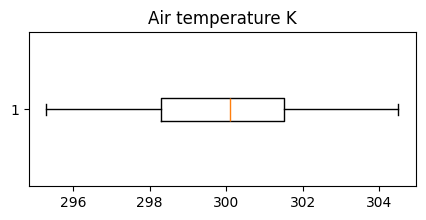

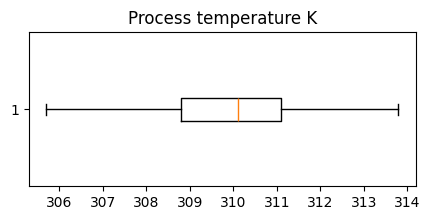

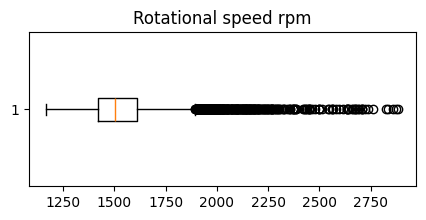

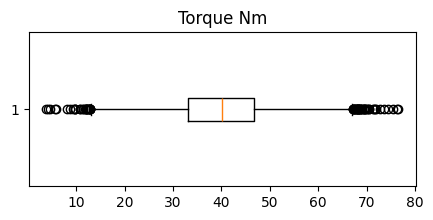

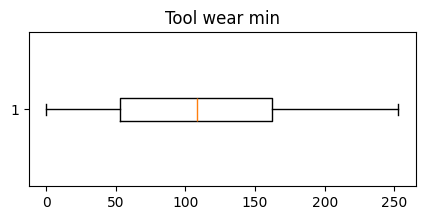

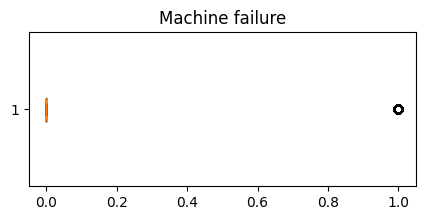

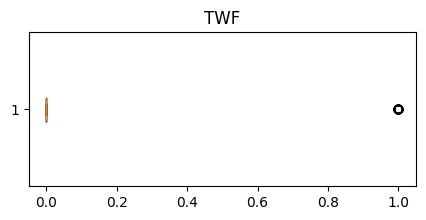

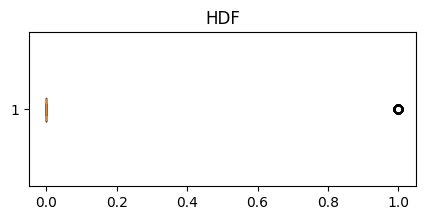

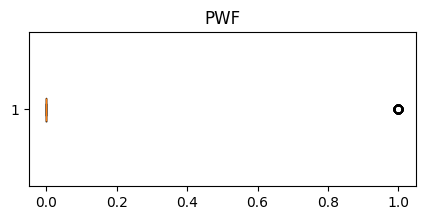

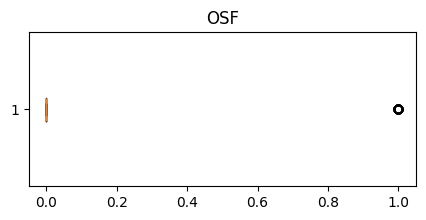

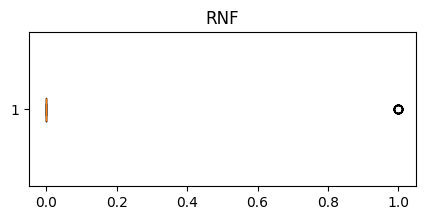

In [19]:
# Visualize outliers
# There're some outliers, but having them in such data is't entry error probably.
# it might be just natural event and having ouliers might be indecators for failures in equipments.
# so we will leave them as they are
for col in num_cols:
    plt.figure(figsize=(5, 2))
    plt.boxplot(df_ai4i[col], vert=False)
    plt.title(col)
    plt.show()

In [20]:
# print the number of unique values per column
for col in df_ai4i.columns:
    print(f"{col}: {df_ai4i[col].nunique()}\n")

Type: 3

Air temperature K: 93

Process temperature K: 82

Rotational speed rpm: 941

Torque Nm: 577

Tool wear min: 246

Machine failure: 2

TWF: 2

HDF: 2

PWF: 2

OSF: 2

RNF: 2



In [21]:
df_ai4i['Type'].unique()
# M = Medium, L = Low, H = High --> quality of the equipment
# can deal with it using numbers that represents the levels

array(['M', 'L', 'H'], dtype=object)

In [22]:
# LOW, MEDIUM, and HIGH --> they suggest order so we will map the values to numbers as type of encoding
level_map = {
    "L": 0,
    "M": 1,
    "H": 2
}

df_ai4i["Type"] = df_ai4i["Type"].map(level_map)

In [23]:
# The type has changed successfully
df_ai4i.head()

,Type,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,0,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,0,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,0,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,0,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Machine failure
0    9661
1     339
Name: count, dtype: int64 




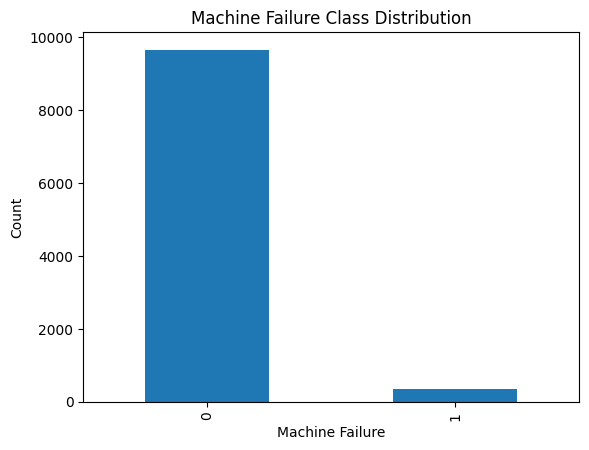

In [24]:
# Check for target imbalance
# the data is highly imbalanced
print(df_ai4i["Machine failure"].value_counts(),'\n\n')
df_ai4i["Machine failure"].value_counts().plot(kind="bar")
plt.title("Machine Failure Class Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.show()

In [25]:
from google.colab import files
uploaded = files.upload()

Saving failure_knowledge_base.csv to failure_knowledge_base (1).csv


# upload new dataset and create new col for the merge

In [26]:
# create new column that contain info of the type of failure, (just to use it next)
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

def get_failure_type(row):
    for col in failure_cols:
        if row[col] == 1:
            return col
    return 'No Failure'

df_ai4i['Failure_Type'] = df_ai4i.apply(get_failure_type, axis=1)

In [27]:
# from the original paper from Rayarao & Rayarao (2024), who analyzed the AI4I 2020 dataset
# they repoted the cost of maintainance of each faliure type
# https://www.techrxiv.org/doi/pdf/10.36227/techrxiv.173397914.41294976/v1?download=true&redirectToLatest=false
kb = pd.read_csv("failure_knowledge_base.csv")

kb.head()

,Failure_Type,Root_Cause,Priority,Estimated_Cost_USD,Cost_Percentage,Recommendation_1,Recommendation_2,Recommendation_3
0,HDF,Overheating and inadequate thermal management,Critical,108000,74.9,Upgrade cooling system,Enable real-time temperature monitoring,Perform regular thermal audits
1,OSF,Excessive mechanical stress or overload,High,16800,11.6,Optimize load distribution,Recalibrate tools,Train operators on safe operating practices
2,PWF,Power interruptions or voltage fluctuations,High,13800,9.6,Install power stabilizers,Add redundant power systems,Perform energy audits
3,TWF,Progressive tool wear due to prolonged usage,Medium,4400,3.1,Replace worn tools,Increase inspection frequency,Monitor tool wear continuously
4,RNF,Random or unidentified operational causes,Low,1200,0.8,Perform general inspection,Review operating conditions,Monitor machine for recurring patterns


In [28]:
df_ai4i = df_ai4i.merge(kb, on="Failure_Type", how="left")

In [29]:
df_ai4i.head()

,Type,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Machine failure,TWF,HDF,PWF,OSF,RNF,Failure_Type,Root_Cause,Priority,Estimated_Cost_USD,Cost_Percentage,Recommendation_1,Recommendation_2,Recommendation_3
0,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,No Failure,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,No Failure,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,No Failure,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,No Failure,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,No Failure,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# fill missing with 0, bcz these are the ones who don't have any type of faliure. so naturaly the cost of repairing is zero
df_ai4i['Estimated_Cost_USD'] = df_ai4i['Estimated_Cost_USD'].fillna(0)
df_ai4i['Cost_Percentage'] = df_ai4i['Cost_Percentage'].fillna(0)

# filling these with explainary values
text_cols = ['Root_Cause', 'Priority', 'Recommendation_1', 'Recommendation_2', 'Recommendation_3']
for col in text_cols:
    df_ai4i[col] = df_ai4i[col].fillna('No Failure - No Action Needed')

In [31]:
# just to check for null values
df_ai4i.isna().sum().sum()

np.int64(0)

In [32]:
df_ai4i.head()

,Type,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Machine failure,TWF,HDF,PWF,OSF,RNF,Failure_Type,Root_Cause,Priority,Estimated_Cost_USD,Cost_Percentage,Recommendation_1,Recommendation_2,Recommendation_3
0,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,No Failure,No Failure - No Action Needed,No Failure - No Action Needed,0.0,0.0,No Failure - No Action Needed,No Failure - No Action Needed,No Failure - No Action Needed
1,0,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,No Failure,No Failure - No Action Needed,No Failure - No Action Needed,0.0,0.0,No Failure - No Action Needed,No Failure - No Action Needed,No Failure - No Action Needed
2,0,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,No Failure,No Failure - No Action Needed,No Failure - No Action Needed,0.0,0.0,No Failure - No Action Needed,No Failure - No Action Needed,No Failure - No Action Needed
3,0,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,No Failure,No Failure - No Action Needed,No Failure - No Action Needed,0.0,0.0,No Failure - No Action Needed,No Failure - No Action Needed,No Failure - No Action Needed
4,0,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,No Failure,No Failure - No Action Needed,No Failure - No Action Needed,0.0,0.0,No Failure - No Action Needed,No Failure - No Action Needed,No Failure - No Action Needed


ready to model for RAG and Modeling (consider dropping some rows to avoide data leakage)

# MODELING ( Classification "Binary, Multi" , Regression )

## Binary Classification:

### splitting the data and importing the important libraries

In [33]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [34]:
# to avoid data leakage we droppped ('TWF', 'HDF', 'PWF', 'OSF', 'RNF)
# we drpped the rest bcz they are irrelevent
df_binary = df_ai4i.drop(columns=[
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF',
    'Failure_Type',
    'Root_Cause',
    'Priority',
    'Estimated_Cost_USD',
    'Cost_Percentage',
    'Recommendation_1',
    'Recommendation_2',
    'Recommendation_3'
])

df_binary.head()

,Type,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Machine failure
0,1,298.1,308.6,1551,42.8,0,0
1,0,298.2,308.7,1408,46.3,3,0
2,0,298.1,308.5,1498,49.4,5,0
3,0,298.2,308.6,1433,39.5,7,0
4,0,298.2,308.7,1408,40.0,9,0


In [35]:
X = df_binary.drop(columns='Machine failure',axis=1)
y = df_binary['Machine failure']

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 , stratify=y)

## 1. XGBoost classifier

In [37]:
# Train
xgb = XGBClassifier(random_state=42).fit(X_train, y_train)

# Predict
y_pred = xgb.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.9865
Precision: 0.8867924528301887
Recall   : 0.6911764705882353
F1-score : 0.7768595041322314

Confusion Matrix
[[1926    6]
 [  21   47]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.89      0.69      0.78        68

    accuracy                           0.99      2000
   macro avg       0.94      0.84      0.88      2000
weighted avg       0.99      0.99      0.99      2000



##2. Randomforest Classifier

In [38]:
# Train
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=300,
    random_state=42
).fit(X_train, y_train)

# Predict
rf_pred = rf.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1-score :", f1_score(y_test, rf_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

Accuracy : 0.984
Precision: 0.875
Recall   : 0.6176470588235294
F1-score : 0.7241379310344828

Confusion Matrix
[[1926    6]
 [  26   42]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.88      0.62      0.72        68

    accuracy                           0.98      2000
   macro avg       0.93      0.81      0.86      2000
weighted avg       0.98      0.98      0.98      2000



## 3. BalancedRandomForestClassifier

In [39]:
# Using BalancedRandomForestClassifier
# the accuracy and Recall are acceptable
# we care about finding about the true actual cases so, we focsed on Recall
# But this suffers from false alarms

# Train
brf = BalancedRandomForestClassifier(
    n_estimators=200,
    random_state=42,
    replacement=True
).fit(X_train, y_train)

# Predict
y_pred = brf.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.9205
Precision: 0.28837209302325584
Recall   : 0.9117647058823529
F1-score : 0.4381625441696113

Confusion Matrix
[[1779  153]
 [   6   62]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.92      0.96      1932
           1       0.29      0.91      0.44        68

    accuracy                           0.92      2000
   macro avg       0.64      0.92      0.70      2000
weighted avg       0.97      0.92      0.94      2000



# RandomizedSearch -> to get the best params

In [40]:
# Model
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

In [41]:
# Calculate class imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos

In [42]:
# the possible values for params
param_dist = {
    "n_estimators": randint(300, 900),
    "max_depth": randint(3, 7),
    "learning_rate": [0.01, 0.03, 0.05, 0.07],
    "min_child_weight": [1,2,3,4],
    "gamma": [0,0.2,0.5,1],
    "subsample": [0.8,0.9,1.0],
    "colsample_bytree": [0.8,0.9,1.0],
    "scale_pos_weight": [
        ratio*0.5,
        ratio*0.75,
        ratio,
        ratio*1.25
    ]
}

In [43]:
# Search
search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
).fit(X_train, y_train)

print(f"\nBest Parameters: {search.best_params_}")
print(f"\nBest CV F1     : {search.best_score_}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters: {'colsample_bytree': 0.9, 'gamma': 0, 'learning_rate': 0.07, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 873, 'scale_pos_weight': np.float64(35.65036900369004), 'subsample': 0.8}

Best CV F1     : 0.7397409816764655


In [44]:
# Best Model
best_model = search.best_estimator_
probs = best_model.predict_proba(X_test)[:,1]

In [45]:
# Threshold Search
best_f1 = 0

for t in [0.20,0.25,0.30,0.35,0.40,0.45,0.50]:

    y_pred = (probs >= t).astype(int)

    acc = accuracy_score(y_test,y_pred)
    pre = precision_score(y_test,y_pred)
    rec = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)

    print("="*50)
    print("Threshold:",t)
    print("Accuracy :",round(acc,4))
    print("Precision:",round(pre,4))
    print("Recall   :",round(rec,4))
    print("F1-score :",round(f1,4))

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("\nBest Threshold =",best_threshold)
print("Best Test F1 =",best_f1)

Threshold: 0.2
Accuracy : 0.9775
Precision: 0.6292
Recall   : 0.8235
F1-score : 0.7134
Threshold: 0.25
Accuracy : 0.978
Precision: 0.6395
Recall   : 0.8088
F1-score : 0.7143
Threshold: 0.3
Accuracy : 0.98
Precision: 0.6707
Recall   : 0.8088
F1-score : 0.7333
Threshold: 0.35
Accuracy : 0.9805
Precision: 0.679
Recall   : 0.8088
F1-score : 0.7383
Threshold: 0.4
Accuracy : 0.981
Precision: 0.6875
Recall   : 0.8088
F1-score : 0.7432
Threshold: 0.45
Accuracy : 0.983
Precision: 0.7237
Recall   : 0.8088
F1-score : 0.7639
Threshold: 0.5
Accuracy : 0.984
Precision: 0.75
Recall   : 0.7941
F1-score : 0.7714

Best Threshold = 0.5
Best Test F1 = 0.7714285714285715


# 2. multi-class classification

In [102]:
# include only the failed cases in a new dataframe
failure_df = df_ai4i[df_ai4i["Machine failure"] == 1].copy()

In [104]:
# count the number of every failure type
# after inspecting RNF seems extemely rare, only one case has RNF
# so we will drop both row and column of this value
failure_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

for col in failure_cols:
    print(f"\n{col}")
    print(failure_df[col].value_counts())


TWF
TWF
0    293
1     46
Name: count, dtype: int64

HDF
HDF
0    224
1    115
Name: count, dtype: int64

PWF
PWF
0    244
1     95
Name: count, dtype: int64

OSF
OSF
0    241
1     98
Name: count, dtype: int64

RNF
RNF
0    338
1      1
Name: count, dtype: int64


In [105]:
# Remove rows where RNF = 1
failure_df = failure_df[failure_df["RNF"] == 0].copy()

# Drop the RNF column
failure_df.drop(columns=["RNF"], inplace=True)

# Check
print(failure_df.shape)
print(failure_df.columns)

(338, 19)
Index(['Type', 'Air temperature K', 'Process temperature K',
       'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'Machine failure',
       'TWF', 'HDF', 'PWF', 'OSF', 'Failure_Type', 'Root_Cause', 'Priority',
       'Estimated_Cost_USD', 'Cost_Percentage', 'Recommendation_1',
       'Recommendation_2', 'Recommendation_3'],
      dtype='object')


In [106]:
# drop the unnessasary columns for predction
# categorical and one hotted columns
failure_df = failure_df.drop(columns=[
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'Machine failure',
    'Root_Cause',
    'Priority',
    'Estimated_Cost_USD',
    'Cost_Percentage',
    'Recommendation_1',
    'Recommendation_2',
    'Recommendation_3'
])

In [107]:
# we won't include the no failure, bcz we will just focus on the failure only
failure_df = failure_df[failure_df["Failure_Type"] != "No Failure"].copy()

In [108]:
failure_df.head()

,Type,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Failure_Type
50,0,298.9,309.1,2861,4.6,143,PWF
69,0,298.9,309.0,1410,65.7,191,PWF
77,0,298.8,308.9,1455,41.3,208,TWF
160,0,298.4,308.2,1282,60.7,216,OSF
161,0,298.3,308.1,1412,52.3,218,OSF


In [109]:
# just encode the target column
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode target column
failure_df["Failure_Type"] = le.fit_transform(failure_df["Failure_Type"])

In [110]:
failure_df.head()

,Type,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Failure_Type
50,0,298.9,309.1,2861,4.6,143,2
69,0,298.9,309.0,1410,65.7,191,2
77,0,298.8,308.9,1455,41.3,208,3
160,0,298.4,308.2,1282,60.7,216,1
161,0,298.3,308.1,1412,52.3,218,1


## split the data

In [111]:
# split into features and target
X = failure_df.drop(columns=["Failure_Type"])
y = failure_df["Failure_Type"]

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## train XGBoost Classifier




In [113]:
# we will train the model and test it
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    random_state=42
).fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8939393939393939

Classification Report
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        23
           1       0.85      0.69      0.76        16
           2       0.94      0.94      0.94        18
           3       0.89      0.89      0.89         9

    accuracy                           0.89        66
   macro avg       0.89      0.88      0.88        66
weighted avg       0.89      0.89      0.89        66


Confusion Matrix
[[23  0  0  0]
 [ 3 11  1  1]
 [ 0  1 17  0]
 [ 0  1  0  8]]
